In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import csv
import requests

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import nltk

# nltk.download('punkt_tab')
# nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemover import StopWordRemover

from wordcloud import WordCloud

from io import StringIO

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense, Dropout,
    Conv1D, GlobalMaxPooling1D, Input
)
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import issparse

In [ ]:
ankidroid_reviews_df = pd.read_csv('ankidroid_reviews.csv')

# Only drop rows missing 'content' — keeps 20K+ samples
ankidroid_reviews_clean_df = ankidroid_reviews_df.dropna(subset=['content'])

In [ ]:
ankidroid_reviews_clean_df = ankidroid_reviews_clean_df.drop_duplicates()

reviews_count_after_delete_duplicate, column_count_after_delete_duplicate = ankidroid_reviews_clean_df.shape

In [ ]:
ankidroid_reviews_clean_df.info()
ankidroid_reviews_clean_df

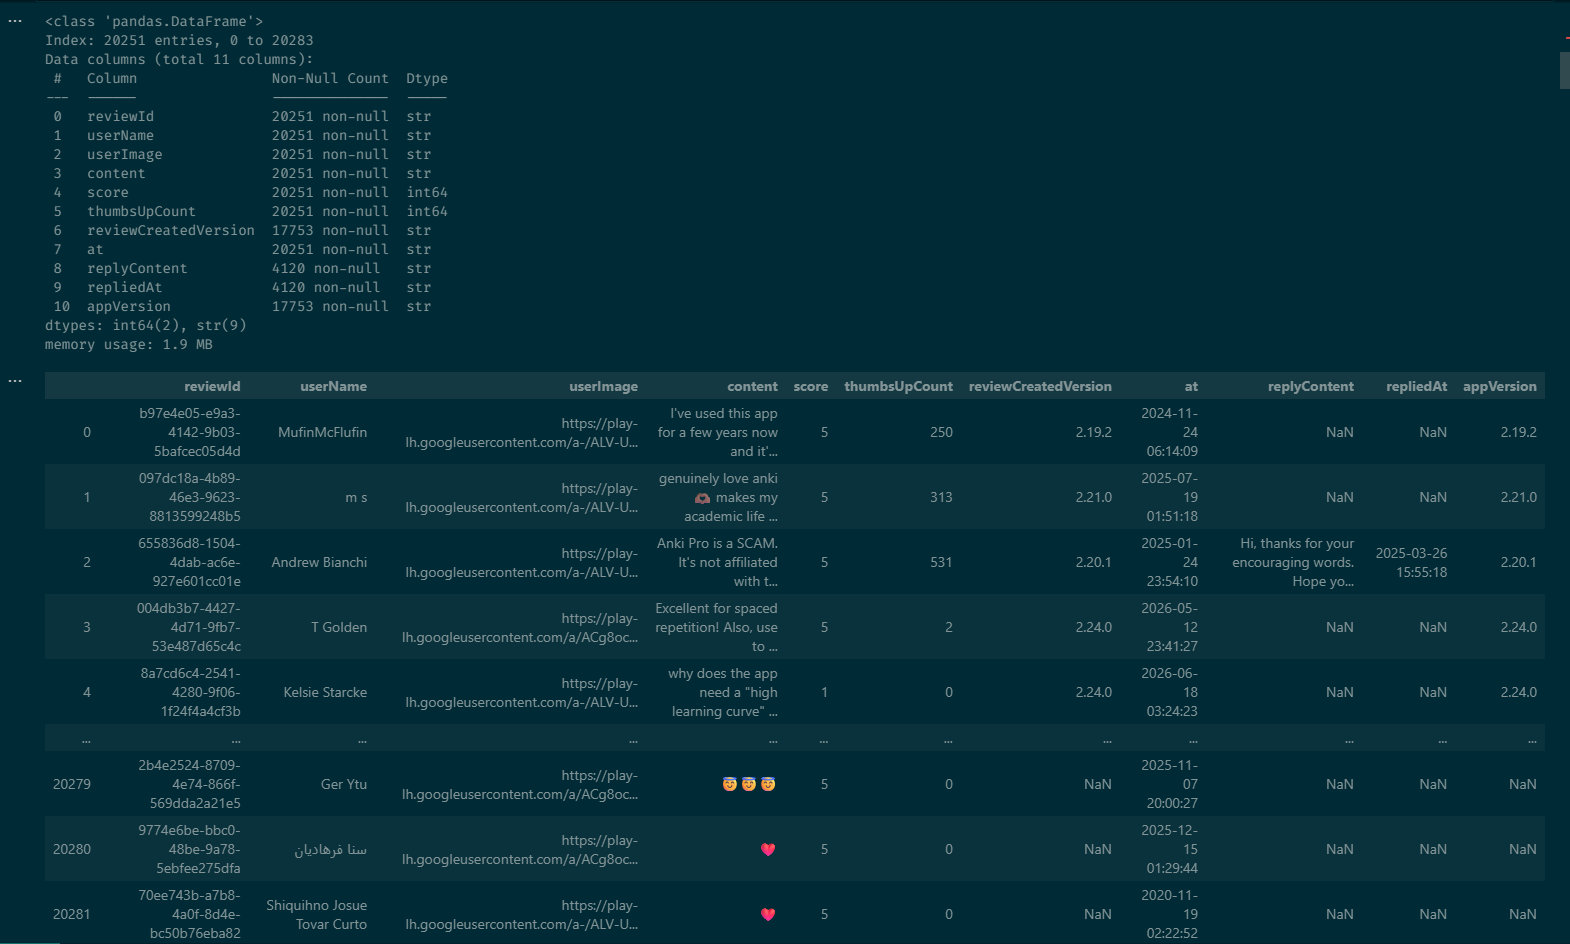

In [ ]:
def cleaning_text(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)   # Remove Metion
    text =  re.sub(r'#[A-Za-z]0-9+', '', text)  # Remove hashtag
    text = re.sub(r'RT[\s]', '', text)  # Remove RT (Retweet)
    text = re.sub(r'http\S+', '', text) # Remove Link
    text = re.sub(r'[0-9]+', '', text)  # Remove Number
    text = re.sub(r'[^\w\s]', '', text) # Remove Character Except Number and Alphabet

    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))

    return text

def casefolding_text(text):
    return text.lower()

def tokenizing_text(text):
    return word_tokenize(text)

def filtering_text(text):
    list_stopwords = set(stopwords.words('english'))

    negations_to_keep = {
        'not', 'no', 'nor', 'don', "don't", 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn'n", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
    }
    list_stopwords = list_stopwords - negations_to_keep

    custom_stopwords = [
        # General
        'app', 'anki', 'ankidroid', 'would', 'also', 'really', 'much', 'ive', 'im', 'get', 'use', 'one', 'even', 'well', 'thats', 'time', 'make', 'way', 'thing', 'things'

        # Flashcard specific
        'card', 'cards', 'deck', 'decks', 'flashcard', 'flashcards', 'study', 'studying', 'studies', 'review', 'reviews',

        # Device Specific
        'phone', 'computer', 'tab', 'tablet', 'ipad', 'android', 'ios', 'version', 'screen',
    ]

    list_stopwords.update(custom_stopwords)

    filtered = []

    for txt in text:
        if txt not in list_stopwords:
            filtered.append(txt)

    return filtered

def stemming_text(text):
    stemmer = PorterStemmer()

    return [stemmer.stem(word) for word in text]

def to_sentence(list_words):
    return ' '.join(word for word in list_words)

In [ ]:
# Cleaning
ankidroid_reviews_clean_df['text_clean'] = ankidroid_reviews_clean_df['content'].apply(cleaning_text)

# Case Folding
ankidroid_reviews_clean_df['text_casefolding'] = ankidroid_reviews_clean_df['text_clean'].apply(casefolding_text)

# Tokenizing
ankidroid_reviews_clean_df['text_tokenized'] = ankidroid_reviews_clean_df['text_casefolding'].apply(tokenizing_text)

# Filtering
ankidroid_reviews_clean_df['text_filtered'] = ankidroid_reviews_clean_df['text_tokenized'].apply(filtering_text)

# Stemming
ankidroid_reviews_clean_df['text_stemmed'] = ankidroid_reviews_clean_df['text_filtered'].apply(stemming_text)

# Join back to sentence
ankidroid_reviews_clean_df['text_final'] = ankidroid_reviews_clean_df['text_stemmed'].apply(to_sentence)

In [ ]:
ankidroid_reviews_clean_df[
    [
        'content', 'text_clean', 'text_casefolding', 'text_tokenized', 'text_filtered', 'text_stemmed', 'text_final'
    ]
].head()

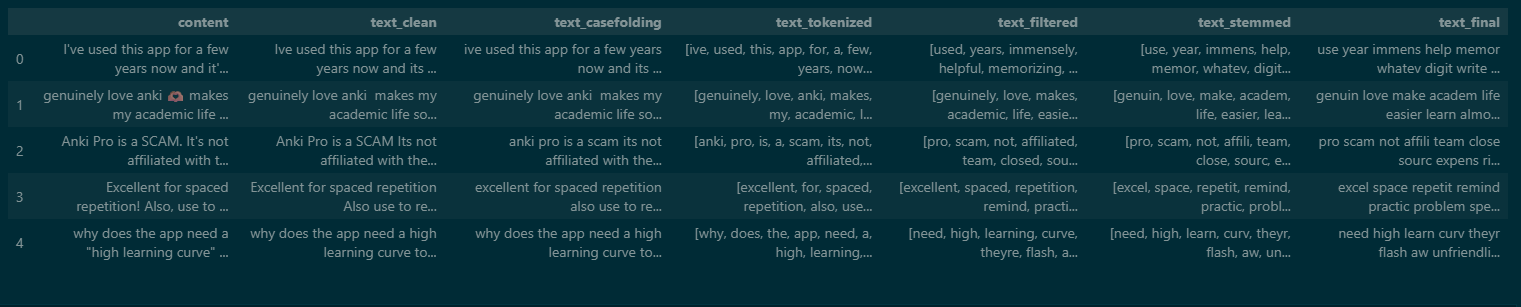

In [ ]:
def score_to_sentiment(score):
    if score >= 4:
        return 'positive'
    elif score <= 2:
        return 'negative'
    else:
        return 'neutral'

In [ ]:
ankidroid_reviews_clean_df['polarity'] = ankidroid_reviews_clean_df['score'].apply(score_to_sentiment)
print(ankidroid_reviews_clean_df['polarity'].value_counts())
print(f'\nTotal samples: {len(ankidroid_reviews_clean_df)}')

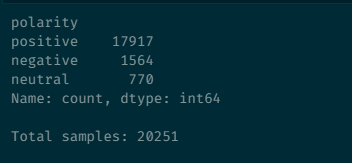

In [ ]:
polarity_counts = ankidroid_reviews_clean_df['polarity'].value_counts()

color_map = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#95a5a6'}
colors = [color_map.get(p, '#34495e') for p in polarity_counts.index.to_list()]
explode = tuple([0.05] * len(polarity_counts))

plt.figure(figsize=(4, 4))
plt.pie(
    polarity_counts,
    labels=polarity_counts.index.to_list(),
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    textprops={
        'fontsize' : 10
    }
)

plt.title('Sentimen Distribution', fontsize=12)
plt.tight_layout()
plt.show()

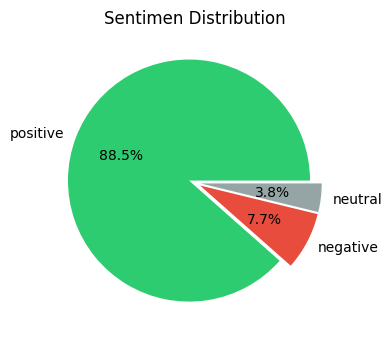

In [ ]:
text_positive = ' '.join(ankidroid_reviews_clean_df[ankidroid_reviews_clean_df['polarity'] == 'positive']['text_final'].astype(str))
text_negative = ' '.join(ankidroid_reviews_clean_df[ankidroid_reviews_clean_df['polarity'] == 'negative']['text_final'].astype(str))

# Generate WordClouds
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

wc_pos = WordCloud(width=400, height=200, background_color='white', colormap='Greens', max_words=100).generate(text_positive)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('WordCloud - Positive Reviews', fontsize=12)
axes[0].axis('off')

wc_neg = WordCloud(width=400, height=200, background_color='white', colormap='Reds', max_words=100).generate(text_negative)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('WordCloud - Negative Reviews', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

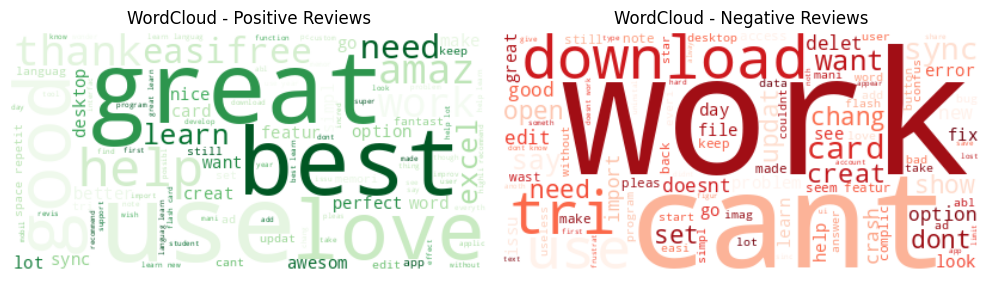

In [ ]:
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
ankidroid_reviews_clean_df['label'] = ankidroid_reviews_clean_df['polarity'].map(label_map)

X_text = ankidroid_reviews_clean_df['text_casefolding'].values
y_labels = ankidroid_reviews_clean_df['label'].values

VOCAB_SIZE = 10000
MAX_LEN = 150

tokenizer_keras = KerasTokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer_keras.fit_on_texts(X_text)
X_sequences = tokenizer_keras.texts_to_sequences(X_text)

from tensorflow.keras.preprocessing.sequence import pad_sequences
X_padded = pad_sequences(X_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_seq, X_test_seq, y_train_12, y_test_12 = train_test_split(
    X_padded, y_labels, test_size=0.2, random_state=42, stratify=y_labels.tolist() # type: ignore
)

y_train_12_cat = to_categorical(y_train_12, num_classes=3)
y_test_12_cat = to_categorical(y_test_12, num_classes=3)

class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train_12), y=y_train_12)
class_weight_dict = dict(enumerate(class_weights_arr))

print(f'Training samples: {len(X_train_seq)}')
print(f'Test samples: {len(X_test_seq)}')
print(f'Vocabulary size: {VOCAB_SIZE}')
print(f'Max sequence length: {MAX_LEN}')
print(f'Class weights: {class_weight_dict}')

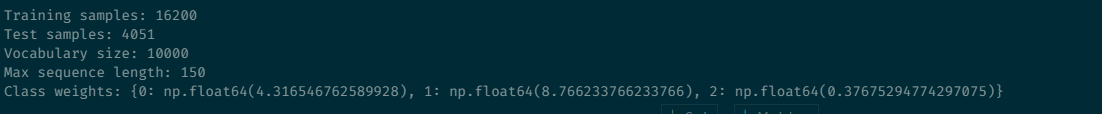

In [ ]:
model_lstm = Sequential([
    Embedding(VOCAB_SIZE, 64, input_length=MAX_LEN),
    Bidirectional(LSTM(32)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_lstm.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_lstm = model_lstm.fit(
    X_train_seq, y_train_12_cat,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
y_pred_train_lstm = np.argmax(model_lstm.predict(X_train_seq), axis=1)
y_pred_test_lstm = np.argmax(model_lstm.predict(X_test_seq), axis=1)

accuracy_train_lstm = accuracy_score(y_train_12, y_pred_train_lstm)
accuracy_test_lstm = accuracy_score(y_test_12, y_pred_test_lstm)

print(f'\n=== Scheme 1: Bi-LSTM + Embedding + 80/20 ===')
print(f'Accuracy_Train: {accuracy_train_lstm}')
print(f'Accuracy_Test: {accuracy_test_lstm}')

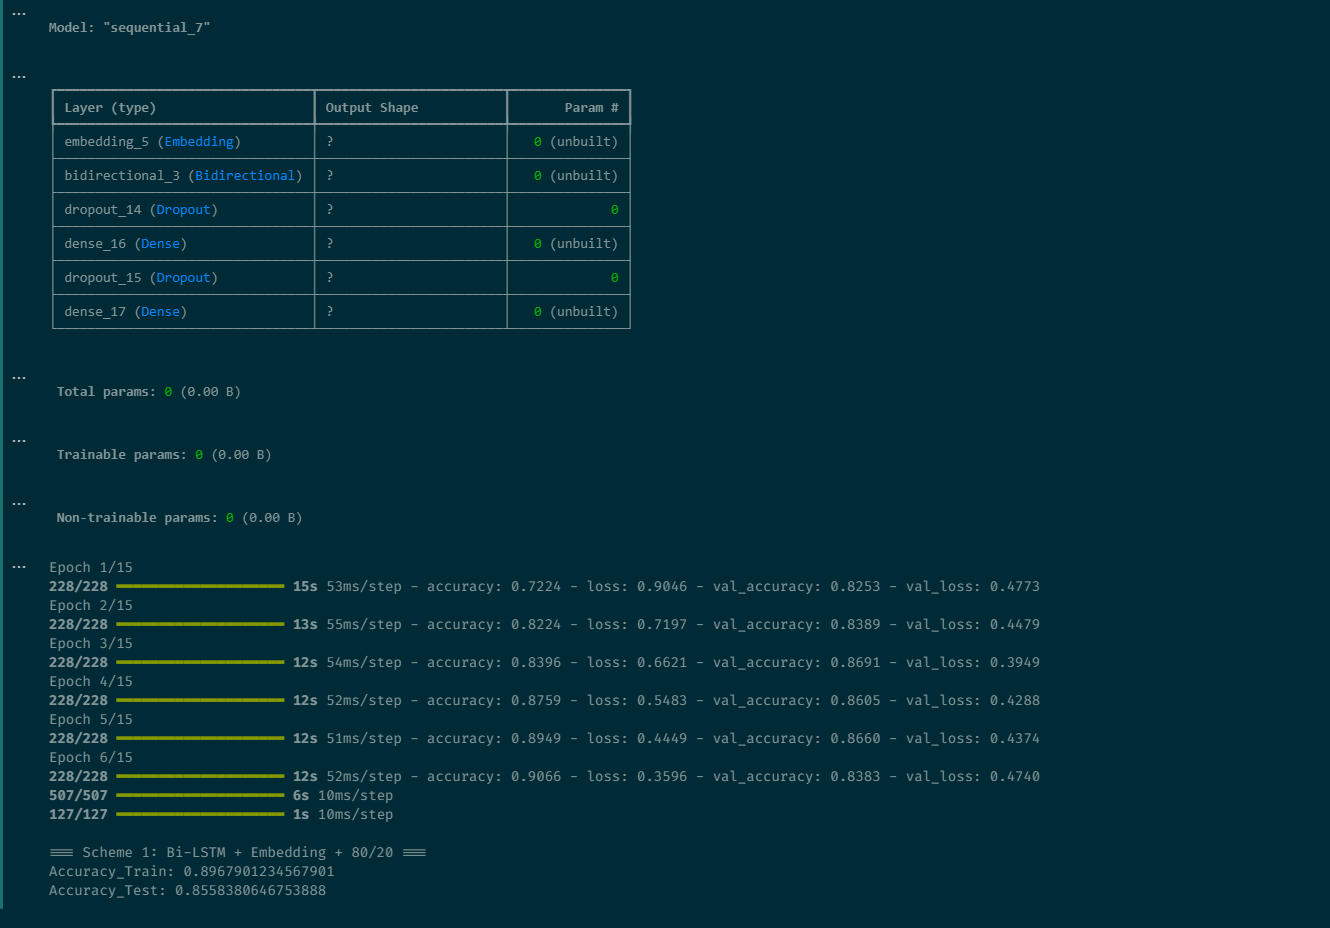

In [ ]:
print('=== Classification Report: Bi-LSTM (Test) ===')
print(classification_report(y_test_12, y_pred_test_lstm, target_names=['negative', 'neutral', 'positive']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_lstm.history['accuracy'], label='Train')
axes[0].plot(history_lstm.history['val_accuracy'], label='Validation')
axes[0].set_title('Bi-LSTM - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_lstm.history['loss'], label='Train')
axes[1].plot(history_lstm.history['val_loss'], label='Validation')
axes[1].set_title('Bi-LSTM - Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

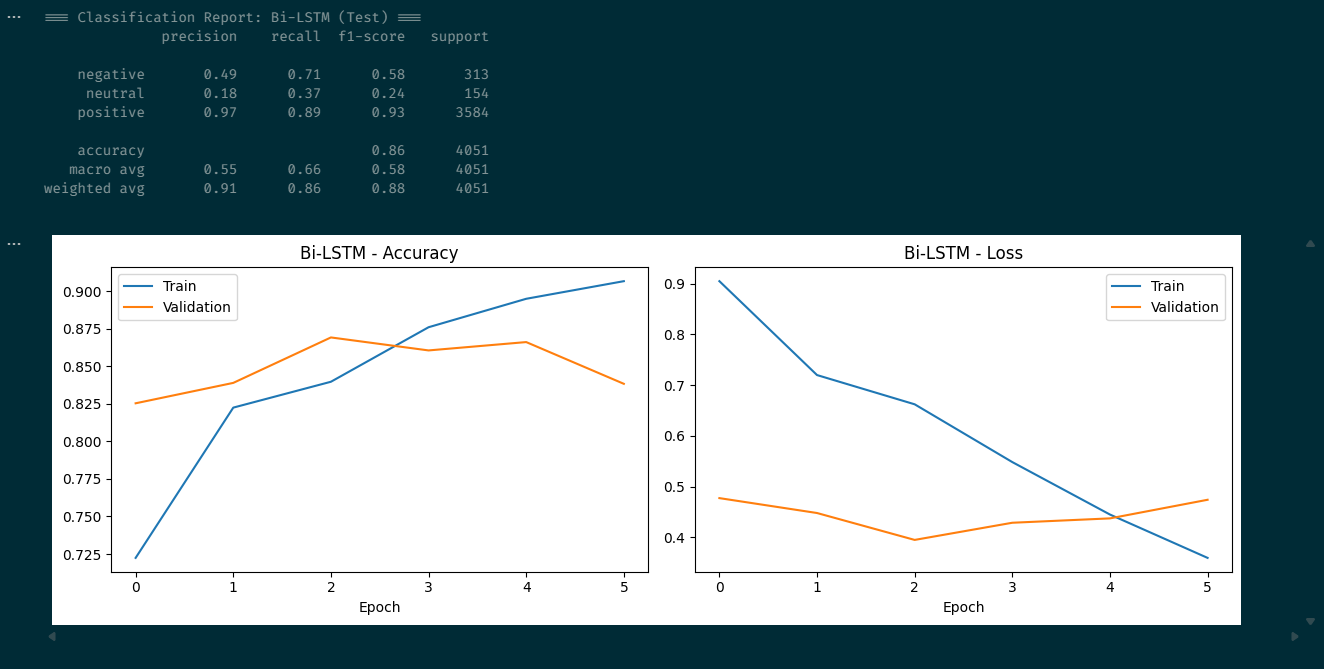

In [ ]:
model_cnn = Sequential([
    Embedding(VOCAB_SIZE, 64, input_length=MAX_LEN),
    Conv1D(64, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()

early_stop_cnn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_cnn = model_cnn.fit(
    X_train_seq, y_train_12_cat,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stop_cnn],
    verbose=1
)

y_pred_train_cnn = np.argmax(model_cnn.predict(X_train_seq), axis=1)
y_pred_test_cnn = np.argmax(model_cnn.predict(X_test_seq), axis=1)

accuracy_train_cnn = accuracy_score(y_train_12, y_pred_train_cnn)
accuracy_test_cnn = accuracy_score(y_test_12, y_pred_test_cnn)

print(f'\n=== Scheme 2: 1D CNN + Embedding + 80/20 ===')
print(f'Accuracy_Train: {accuracy_train_cnn}')
print(f'Accuracy_Test: {accuracy_test_cnn}')

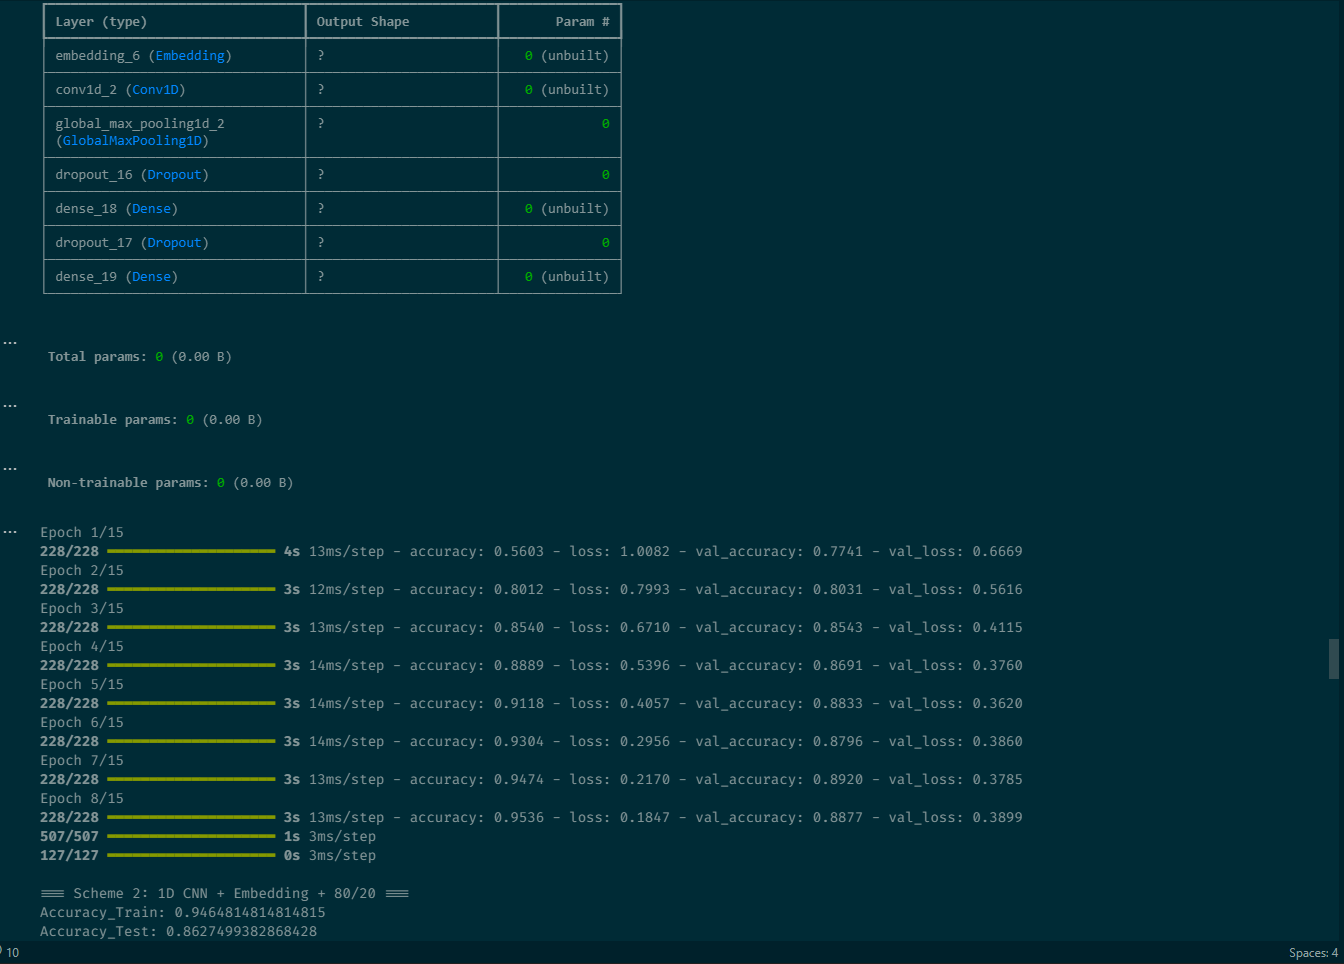

In [ ]:
print('=== Classification Report: 1D CNN (Test) ===')
print(classification_report(y_test_12, y_pred_test_cnn, target_names=['negative', 'neutral', 'positive']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_cnn.history['accuracy'], label='Train')
axes[0].plot(history_cnn.history['val_accuracy'], label='Validation')
axes[0].set_title('1D CNN - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_cnn.history['loss'], label='Train')
axes[1].plot(history_cnn.history['val_loss'], label='Validation')
axes[1].set_title('1D CNN - Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

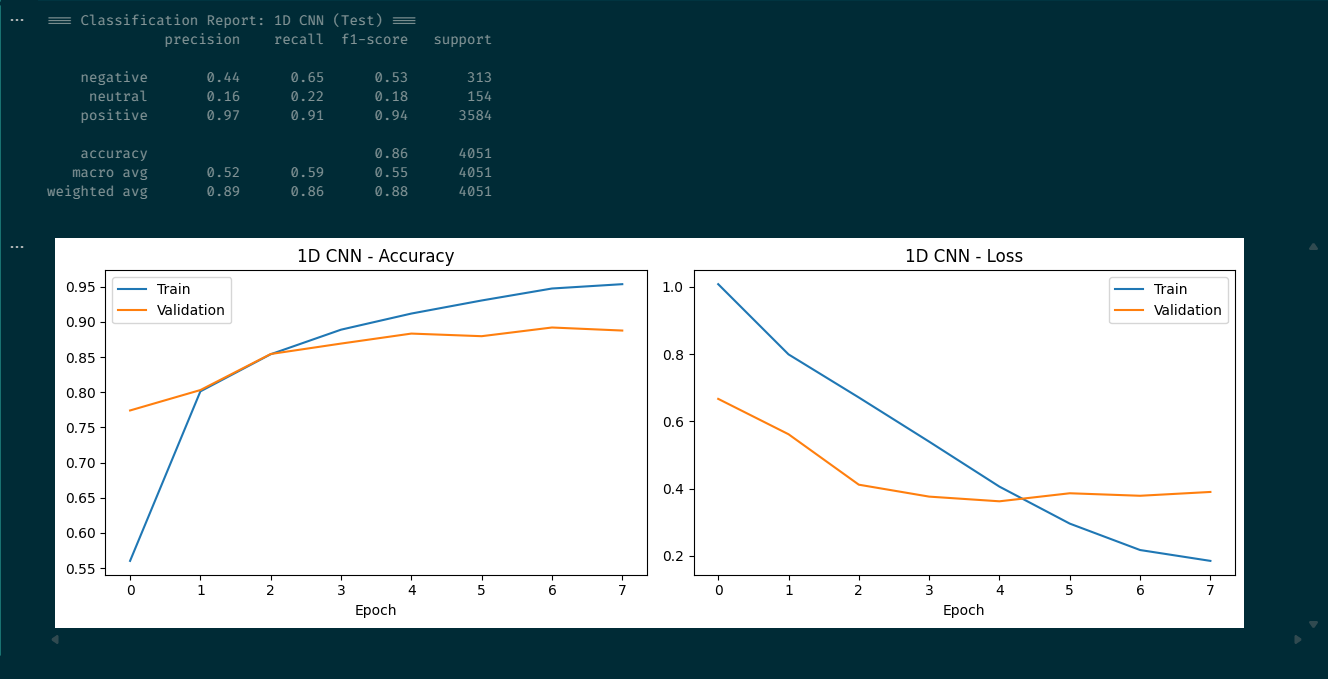

In [ ]:
tfidf = TfidfVectorizer(max_features=10000, min_df=2, max_df=0.95, ngram_range=(1, 2), sublinear_tf=True)
X_tfidf = tfidf.fit_transform(ankidroid_reviews_clean_df['text_casefolding'])

y_labels_all = ankidroid_reviews_clean_df['label'].values

X_train_tfidf, X_test_tfidf, y_train_3, y_test_3 = train_test_split(
    X_tfidf, y_labels_all, test_size=0.3, random_state=42, stratify=y_labels_all.tolist() # type: ignore
)

X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

y_train_3_cat = to_categorical(y_train_3, num_classes=3)
y_test_3_cat = to_categorical(y_test_3, num_classes=3)

class_weights_3 = compute_class_weight('balanced', classes=np.unique(y_train_3), y=y_train_3)
class_weight_dict_3 = dict(enumerate(class_weights_3))

model_dense = Sequential([
    Input(shape=(X_train_dense.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_dense.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_dense.summary()

early_stop_dense = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_dense = model_dense.fit(
    X_train_dense, y_train_3_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    class_weight=class_weight_dict_3,
    callbacks=[early_stop_dense],
    verbose=1
)

# Evaluate
y_pred_train_dense = np.argmax(model_dense.predict(X_train_dense), axis=1)
y_pred_test_dense = np.argmax(model_dense.predict(X_test_dense), axis=1)

accuracy_train_dense = accuracy_score(y_train_3, y_pred_train_dense)
accuracy_test_dense = accuracy_score(y_test_3, y_pred_test_dense)

print(f'\n=== Scheme 3: Dense NN + TF-IDF + 70/30 ===')
print(f'Accuracy_Train: {accuracy_train_dense}')
print(f'Accuracy_Test: {accuracy_test_dense}')

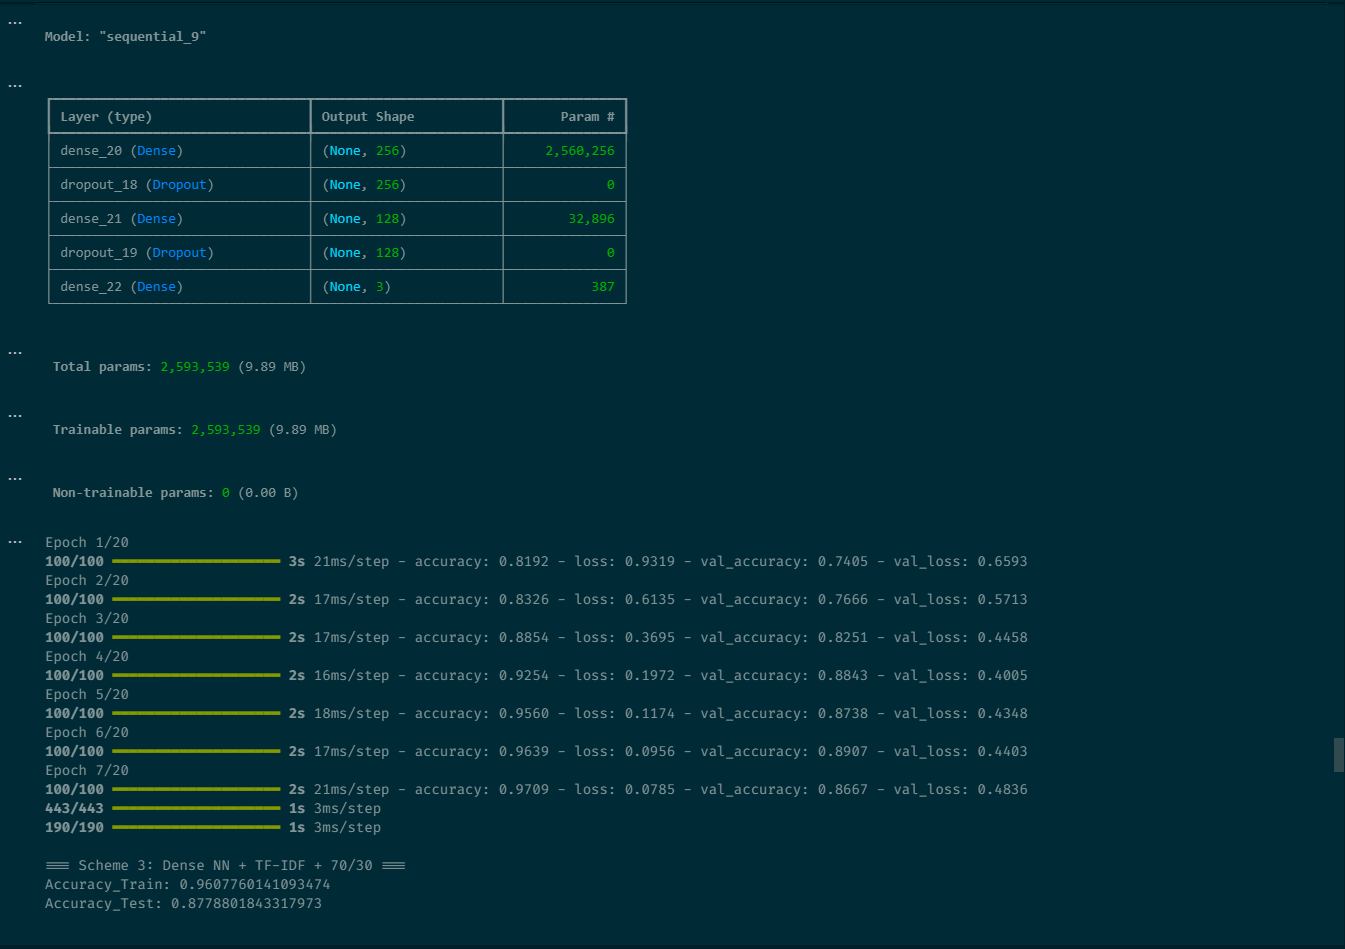

In [ ]:
print('=== Classification Report: Dense NN + TF-IDF (Test) ===')
print(classification_report(y_test_3, y_pred_test_dense, target_names=['negative', 'neutral', 'positive']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_dense.history['accuracy'], label='Train')
axes[0].plot(history_dense.history['val_accuracy'], label='Validation')
axes[0].set_title('Dense NN - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_dense.history['loss'], label='Train')
axes[1].plot(history_dense.history['val_loss'], label='Validation')
axes[1].set_title('Dense NN - Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

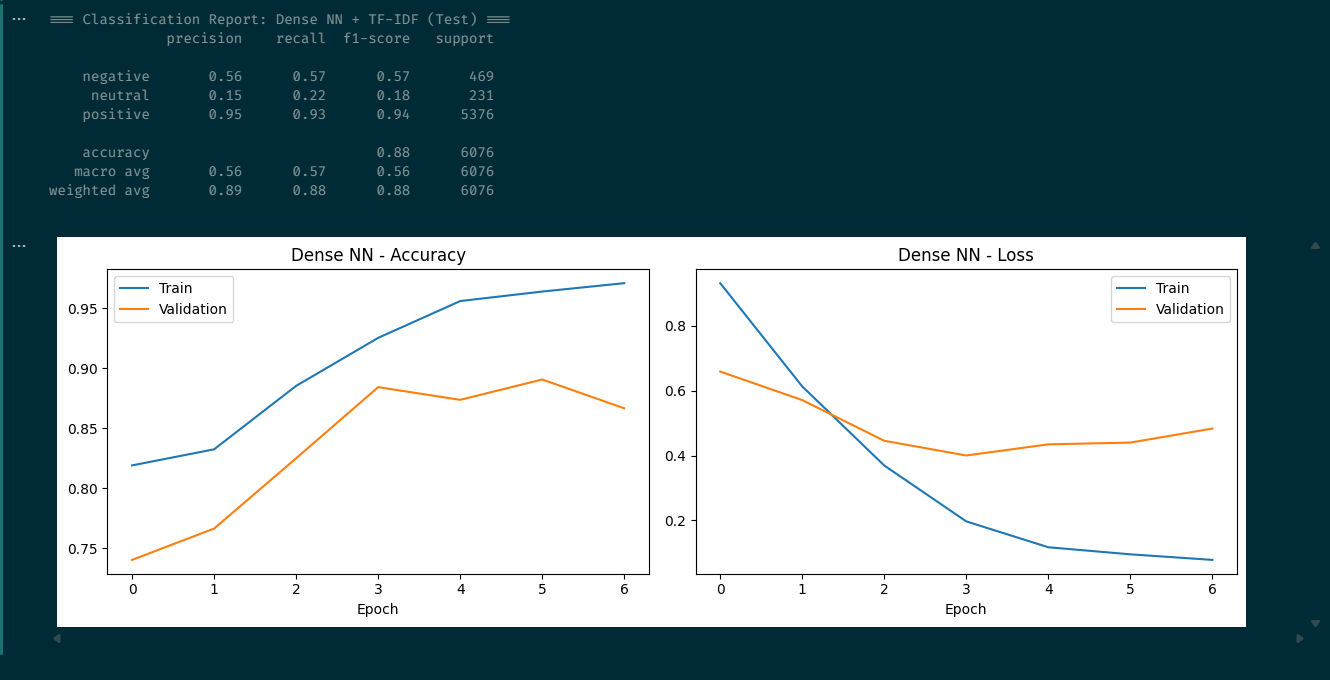

In [ ]:
tfidf = TfidfVectorizer(max_features=10000, min_df=2, max_df=0.95, ngram_range=(1, 2), sublinear_tf=True)
X_tfidf = tfidf.fit_transform(ankidroid_reviews_clean_df['text_casefolding'])

y_labels_all = ankidroid_reviews_clean_df['label'].values

X_train_tfidf, X_test_tfidf, y_train_3, y_test_3 = train_test_split(
    X_tfidf, y_labels_all, test_size=0.3, random_state=42, stratify=y_labels_all  # type: ignore
)

X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

y_train_3_cat = to_categorical(y_train_3, num_classes=3)
y_test_3_cat = to_categorical(y_test_3, num_classes=3)

class_weights_3 = compute_class_weight('balanced', classes=np.unique(y_train_3), y=y_train_3)
class_weight_dict_3 = dict(enumerate(class_weights_3))

model_dense = Sequential([
    Input(shape=(X_train_dense.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_dense.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_dense.summary()

early_stop_dense = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_dense = model_dense.fit(
    X_train_dense, y_train_3_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    class_weight=class_weight_dict_3,
    callbacks=[early_stop_dense],
    verbose=1
)

y_pred_train_dense = np.argmax(model_dense.predict(X_train_dense), axis=1)
y_pred_test_dense = np.argmax(model_dense.predict(X_test_dense), axis=1)

accuracy_train_dense = accuracy_score(y_train_3, y_pred_train_dense)
accuracy_test_dense = accuracy_score(y_test_3, y_pred_test_dense)

print(f'\n=== Scheme 3: Dense NN + TF-IDF + 70/30 ===')
print(f'Accuracy_Train: {accuracy_train_dense}')
print(f'Accuracy_Test: {accuracy_test_dense}')

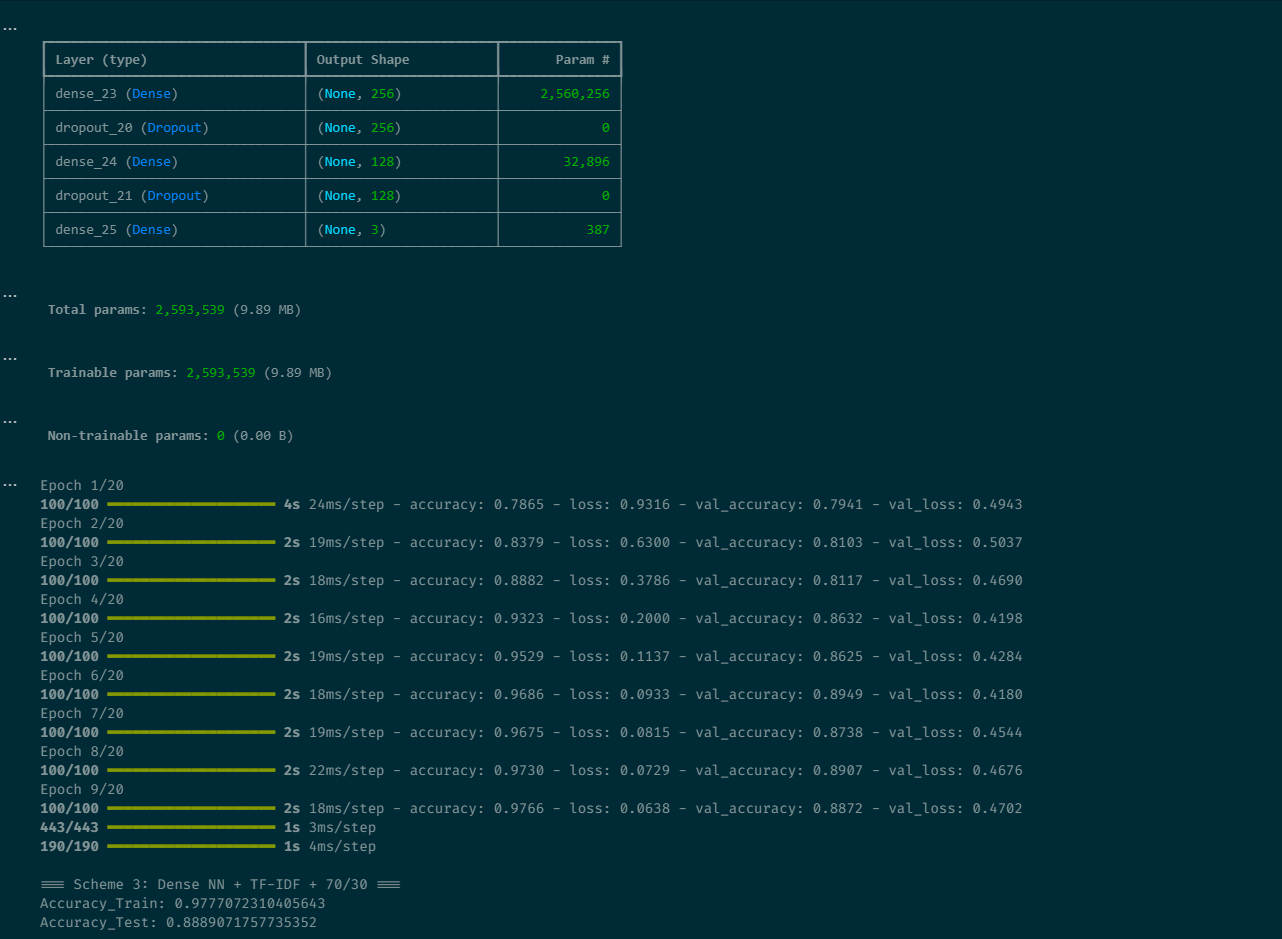

In [ ]:
print('=== Classification Report: Dense NN + TF-IDF (Test) ===')
print(classification_report(y_test_3, y_pred_test_dense, target_names=['negative', 'neutral', 'positive']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_dense.history['accuracy'], label='Train')
axes[0].plot(history_dense.history['val_accuracy'], label='Validation')
axes[0].set_title('Dense NN - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_dense.history['loss'], label='Train')
axes[1].plot(history_dense.history['val_loss'], label='Validation')
axes[1].set_title('Dense NN - Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

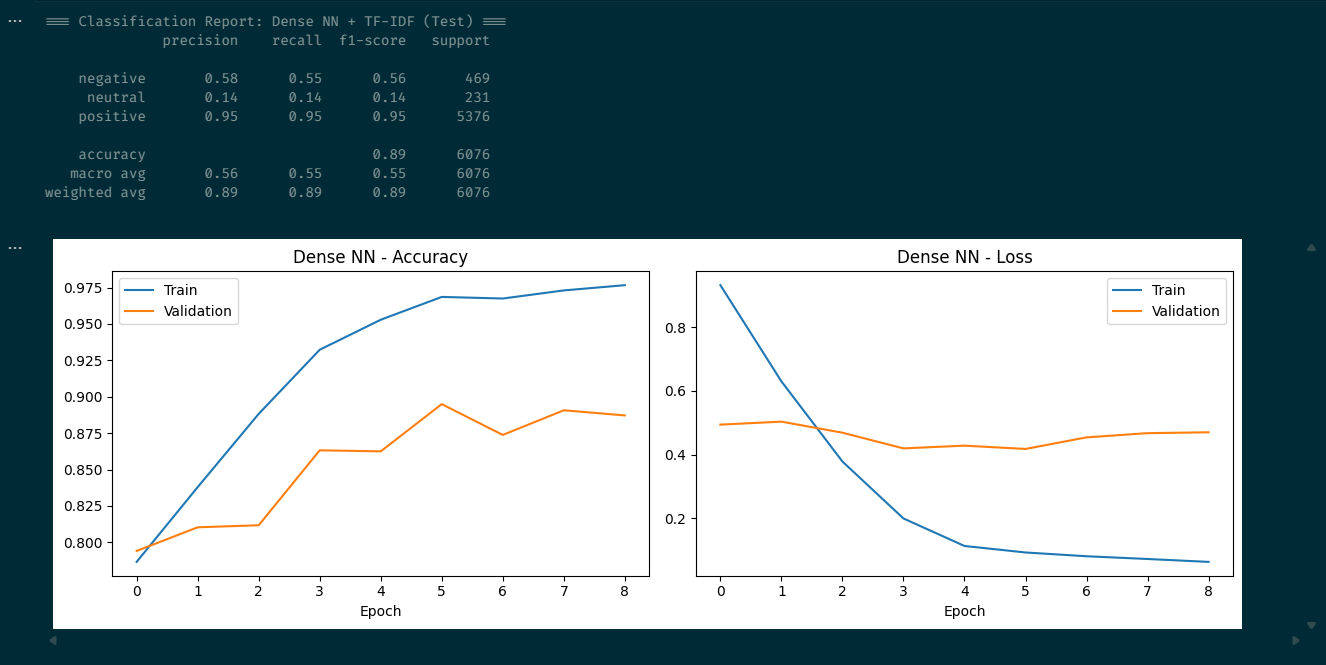

In [ ]:
print("--- Training Traditional ML Models ---\n")

# 1. Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf_model.fit(X_train_tfidf, y_train_3)

y_pred_train_rf = rf_model.predict(X_train_tfidf)
y_pred_test_rf = rf_model.predict(X_test_tfidf)

accuracy_train_rf = accuracy_score(y_train_3, y_pred_train_rf)
accuracy_test_rf = accuracy_score(y_test_3, y_pred_test_rf)

print("Random Forest Accuracy_Train:", accuracy_train_rf)
print("Random Forest Accuracy_Test:", accuracy_test_rf)
print("Random Forest Classification Report:")
print(classification_report(y_test_3, y_pred_test_rf))
print("="*50 + "\n")


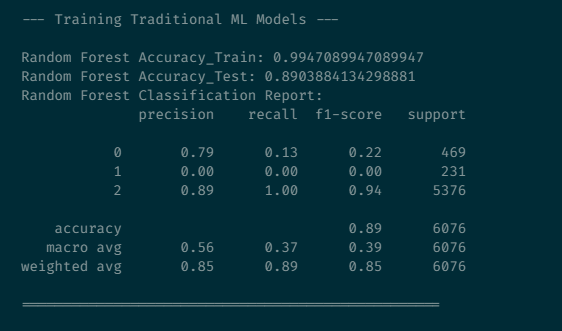

In [ ]:
# 2. Logistic Regression 

lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr_model.fit(X_train_tfidf, y_train_3)

y_pred_train_lr = lr_model.predict(X_train_tfidf)
y_pred_test_lr = lr_model.predict(X_test_tfidf)

accuracy_train_lr = accuracy_score(y_train_3, y_pred_train_lr)
accuracy_test_lr = accuracy_score(y_test_3, y_pred_test_lr)

print("Logistic Regression Accuracy_Train:", accuracy_train_lr)
print("Logistic Regression Accuracy_Test:", accuracy_test_lr)
print("Logistic Regression Classification Report:")
print(classification_report(y_test_3, y_pred_test_lr))
print("="*50 + "\n")


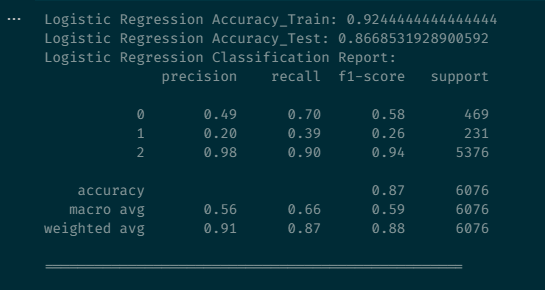

In [ ]:
# 3. Naive Bayes Classifier
nb_model = BernoulliNB()
nb_model.fit(X_train_tfidf, y_train_3)

y_pred_train_nb = nb_model.predict(X_train_tfidf)
y_pred_test_nb = nb_model.predict(X_test_tfidf)

accuracy_train_nb = accuracy_score(y_train_3, y_pred_train_nb)
accuracy_test_nb = accuracy_score(y_test_3, y_pred_test_nb)

print("Naive Bayes Accuracy_Train:", accuracy_train_nb)
print("Naive Bayes Accuracy_Test:", accuracy_test_nb)
print("Naive Bayes Classification Report:")
print(classification_report(y_test_3, y_pred_test_nb))


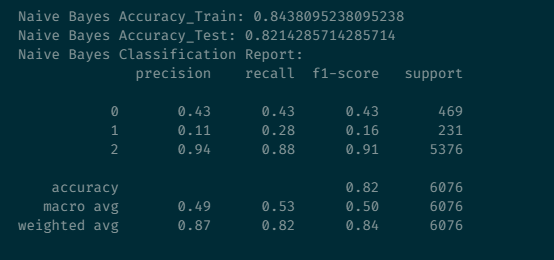

In [ ]:
# === SCHEME 5: INFERENCE / TESTING ===
def predict_sentiment(text, model, vectorizer):
    cleaned = cleaning_text(text)
    casefolded = casefolding_text(cleaned)
    tokenized = tokenizing_text(casefolded)
    filtered = filtering_text(tokenized)
    stemmed = stemming_text(filtered)
    final_text = to_sentence(stemmed)
    
    vectorized_text = vectorizer.transform([final_text])
    
    pred = model.predict(vectorized_text)[0]
    
    sentiment_map = {0: "negatif", 1: "netral", 2: "positif"}
    return sentiment_map[pred]

test_sentences = [
    "Aplikasi ini sangat bagus dan sangat membantu saya belajar untuk ujian!",
    "Banyak bug, aplikasinya sering crash saat saya membuka deck kartu.",
    "Aplikasi ini lumayan, tapi butuh banyak perbaikan dari sisi UI."
]

print("--- Hasil Inferensi Menggunakan Random Forest ---")
for sentence in test_sentences:
    print(f"Teks: {sentence}")
    print(f"Prediksi: {predict_sentiment(sentence, rf_model, tfidf)}\n")

print("--- Hasil Inferensi Menggunakan Logistic Regression ---")
for sentence in test_sentences:
    print(f"Teks: {sentence}")
    print(f"Prediksi: {predict_sentiment(sentence, lr_model, tfidf)}\n")

print("--- Hasil Inferensi Menggunakan Naive Bayes ---")
for sentence in test_sentences:
    print(f"Teks: {sentence}")
    print(f"Prediksi: {predict_sentiment(sentence, nb_model, tfidf)}\n")


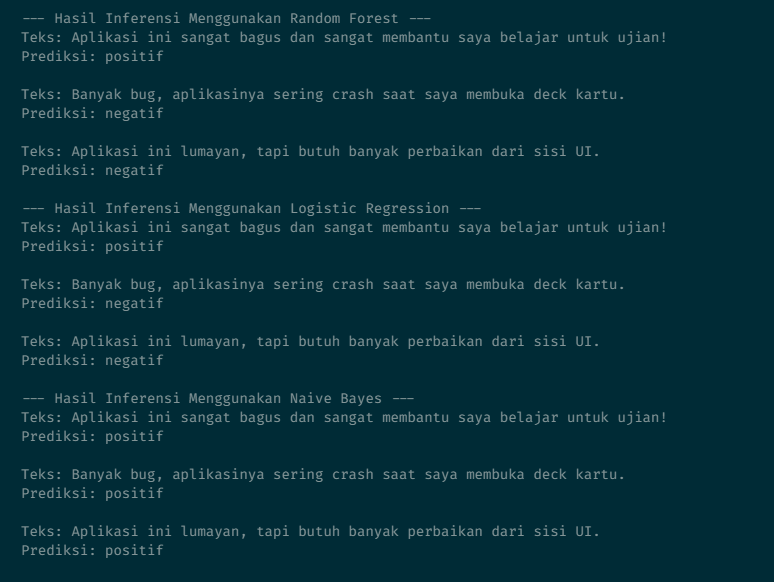